# Bike-Sharing Rental Demand Prediction

## 1. Business Objective:
### Problem Statement 

The objective of this project is to predict the demand for bike rentals in urban cities using historical data. 

Accurate demand prediction helps bike-sharing companies: 

Maintain a stable supply of bikes 

Reduce waiting time for customers 

Optimize pricing and operational strategies 

Improve customer satisfaction 

The prediction is based on external factors such as weather conditions, seasonality, holidays, and time features.

## 2. Import Required Libraries:

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

## 3. Load the Dataset :

In [2]:
df = pd.read_csv("Dataset.csv") 
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


## 4. Exploratory Data Analysis (EDA): 
### 4.1 Dataset Overview:

In [3]:
df.shape 
df.info() 
df.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


### 4.2 Check Missing Values :

In [4]:
df.isnull().sum() 

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

#### Observation: 
The dataset does not contain missing values (as per UCI Bike Sharing dataset).

### 4.3 Check Duplicates:

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes


instant        int64
dteday        object
season        object
yr            object
mnth          object
hr             int64
holiday       object
weekday        int64
workingday    object
weathersit    object
temp          object
atemp         object
hum           object
windspeed     object
casual        object
registered    object
cnt            int64
dtype: object

In [7]:
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True,errors='coerce')


In [8]:
df['dteday'].isnull().sum()

np.int64(0)

In [9]:
df['day'] = df['dteday'].dt.day
df['month'] = df['dteday'].dt.month
df['year'] = df['dteday'].dt.year
df['dayofweek'] = df['dteday'].dt.dayofweek

In [10]:
df.drop('dteday', axis=1, inplace=True)


In [11]:
default_values = {
    'season': 1,        # default season
    'holiday': 0,       # not a holiday
    'workingday': 1,    # working day
    'weathersit': 1     # clear weather
}

for col, val in default_values.items():
    df[col] = df[col].fillna(val)

In [12]:
num_cols = ['season','yr','mnth','holiday','workingday',
            'weathersit','temp','atemp','hum','windspeed',
            'casual','registered']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [13]:
df.isnull().sum()


instant           0
season        17379
yr                1
mnth              1
hr                0
holiday       17379
weekday           0
workingday    17379
weathersit    17379
temp             11
atemp             6
hum               6
windspeed         5
casual            1
registered        1
cnt               0
day               0
month             0
year              0
dayofweek         0
dtype: int64

In [67]:
df.fillna(df.median(numeric_only=True), inplace=True)


In [68]:
df.dtypes

instant         int64
season        float64
yr            float64
mnth          float64
hr              int64
holiday       float64
weekday         int64
workingday    float64
weathersit    float64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual        float64
registered    float64
cnt             int64
day             int32
month           int32
year            int32
dayofweek       int32
dtype: object

In [69]:
df.isna().sum()

instant           0
season        17379
yr                0
mnth              0
hr                0
holiday       17379
weekday           0
workingday    17379
weathersit    17379
temp              0
atemp             0
hum               0
windspeed         0
casual            0
registered        0
cnt               0
day               0
month             0
year              0
dayofweek         0
dtype: int64

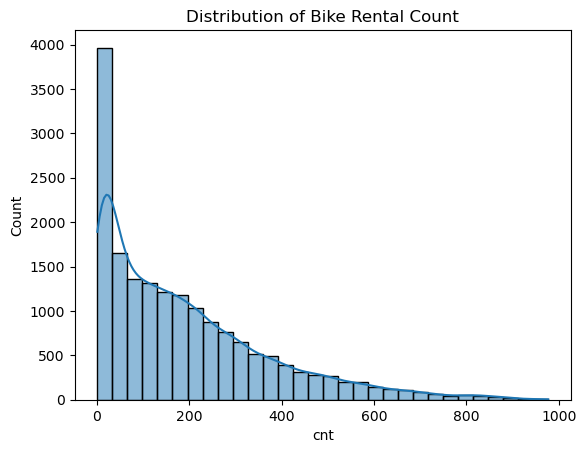

In [48]:
sns.histplot(df['cnt'], bins=30, kde=True) 
plt.title("Distribution of Bike Rental Count") 
plt.show() 

### 5.2 Correlation Heatmap:

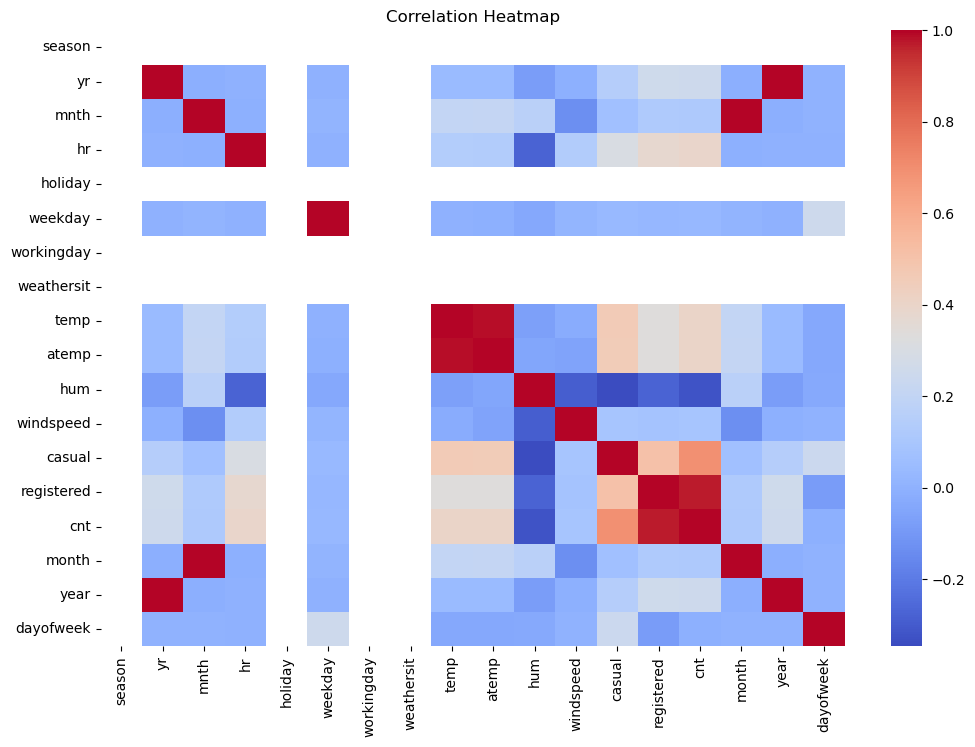

In [49]:
plt.figure(figsize=(12,8)) 
sns.heatmap(df.corr(), cmap='coolwarm', annot=False) 
plt.title("Correlation Heatmap") 
plt.show() 

#### Insight: 
Temperature, season, and working day have strong influence on bike rentals. 

In [71]:
categorical_cols = ['season', 'holiday', 'workingday', 'weathersit']

for col in categorical_cols:
    df[col] = df[col].astype(int)
    

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
df[categorical_cols].dtypes

## 6. Feature Engineering :
### 6.1 Drop Unnecessary Columns: 

In [53]:
df.drop(['instant', 'day'], axis=1, inplace=True) 

KeyError: "['instant', 'day'] not found in axis"

These columns do not contribute to prediction.

### 6.2 Define Features and Target:

In [24]:
X = df.drop('cnt', axis=1) 
y = df['cnt'] 

## 7. Train-Test Split :

In [25]:
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.2, random_state=42 
)

In [70]:
X_train.isnull().sum()

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [38]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

C:\Users\Prince Soni\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['season' 'holiday' 'workingday' 'weathersit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Prince Soni\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['season' 'holiday' 'workingday' 'weathersit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 8. Model Building :
### 8.1 Decision Tree Regressor (Baseline Model) :

In [26]:
dt = DecisionTreeRegressor(random_state=42) 
dt.fit(X_train, y_train) 

DecisionTreeRegressor(random_state=42)

### 8.2 Evaluate Decision Tree :

In [27]:
y_pred_dt = dt.predict(X_test) 
print("MAE:", mean_absolute_error(y_test, y_pred_dt)) 
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt))) 
print("R2 Score:", r2_score(y_test, y_pred_dt)) 

MAE: 2.278481012658228
RMSE: 5.693403608477258
R2 Score: 0.998976332746649


## 9. Hyperparameter Tuning :
#### Why Hyperparameter Tuning? 
 
Decision Trees can overfit. Hyperparameter tuning helps balance model complexity and performance. 


### 9.1 Define Parameter Grid:

In [28]:
param_grid = { 
    'max_depth': [5, 10, 15, None], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 5] 
} 

### 9.2 GridSearchCV:

In [29]:
grid_dt = GridSearchCV( 
    DecisionTreeRegressor(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error' 
) 
 
grid_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

### 9.3 Best Parameters :

In [30]:
grid_dt.best_params_ 

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

### 9.4 Train Tuned Decision Tree :

In [32]:
best_dt = grid_dt.best_estimator_ 
best_dt.fit(X_train, y_train)

DecisionTreeRegressor(min_samples_leaf=2, min_samples_split=5, random_state=42)

### 9.5 Tuned Model Evaluation:

In [33]:
y_pred_best_dt = best_dt.predict(X_test) 
print("MAE:", mean_absolute_error(y_test, y_pred_best_dt)) 
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_dt))) 
print("R2 Score:", r2_score(y_test, y_pred_best_dt))

MAE: 2.1799721902570006
RMSE: 4.984260925314293
R2 Score: 0.9992154576263782


## 10. Advanced Models :

### 10.1 Random Forest Regressor :

In [35]:
rf = RandomForestRegressor(random_state=42) 
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test) 
print("Random Forest R2:", r2_score(y_test, y_pred_rf)) 

Random Forest R2: 0.9997623549230431


### 10.2 Gradient Boosting Regressor:

In [36]:
gbr = GradientBoostingRegressor(random_state=42) 
gbr.fit(X_train, y_train) 
y_pred_gbr = gbr.predict(X_test) 
print("Gradient Boosting R2:", r2_score(y_test, y_pred_gbr)) 

ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values